# 04 — MACE for Reactions: Transition States and Activation Barriers
### CO diffusion on Cu(111)

In 01 we trained MACE from scratch for CO/Cu(111) and ran stable MD.
In 02 we fixed a bad model using iterative training and active learning.

**Now we ask: How does CO actually move across the surface?**

We use the 01 model to compute the **minimum energy path** for CO
diffusion between adsorption sites and extract the **activation barrier**
and **diffusion rate**. In this way we connect atomistic simulation to
experimentally measurable quantities.

---

## Learning Objectives

| Section | Topic | Key concept |
|---------|-------|-------------|
| 1 | MEP scan | Manual energy profile along a diffusion path |
| 2 | Nudged Elastic Band | Finding the true minimum energy path |
| 3 | Arrhenius kinetics | Converting barriers to diffusion rates |

---

## What you need from 01

- The trained model: `MACE_models/mace_CO_Cu111_run-42_stagetwo.model`
- The dataset: `data/CO_Cu111_emt.xyz`
- Understanding of: slab geometry, ASE tags, MACE calculators

> 💡 If starting fresh without 01, run Cell 3 which regenerates
> the 01 model automatically.

> 💡 **GPU recommended:** Runtime → Change runtime type → T4 GPU → Save

---

## Scientific background

CO diffusion on Cu(111) is a well-studied system:

```
Experimentally: CO is highly mobile on Cu(111) at 300 K
               diffusion barrier ~ 10–60 meV (STM measurements)
               hops between hollow sites on ps timescales

EMT/DFT-PBE:   predicts fcc hollow as preferred site (wrong)
               but diffusion barrier is qualitatively correct

Our MACE model: trained on EMT → reproduces EMT kinetics
               barrier from NEB ~ 16 meV (MACE), 8 meV (EMT)
```

> ⚠️ As in 01/02, our model reproduces EMT — not experiment.
> For quantitative barriers use DFT-level reference data.

In [ ]:
# ============================================================
# Installation & persistent storage setup
# Run this first — takes ~2-3 minutes on first run
# ============================================================

!pip install mace-torch --quiet
!pip install ase --quiet
!pip install tqdm --quiet

from google.colab import drive
import os, shutil

drive.mount('/content/drive', force_remount=True)

DRIVE_DIR = "/content/drive/MyDrive/MACE_Surface_Tutorials"

for d in ["data", "config", "MACE_models", "tests", "moldyn"]:
    os.makedirs(f"{DRIVE_DIR}/{d}", exist_ok=True)
    local  = f"/content/{d}"
    remote = f"{DRIVE_DIR}/{d}"

    if os.path.islink(local):
        pass
    elif os.path.isdir(local):
        for item in os.listdir(local):
            src = f"{local}/{item}"
            dst = f"{remote}/{item}"
            if os.path.isfile(src):
                shutil.copy2(src, dst)
        shutil.rmtree(local)
        os.symlink(remote, local)
    else:
        os.symlink(remote, local)

    n = len(os.listdir(local))
    print(f"  📁 {local} → Drive  ({n} files)")

print(f"\n✅ Storage ready → {DRIVE_DIR}")
print(f"   Files persist across Colab restarts")

Mounted at /content/drive
  📁 /content/data → Drive  (9 files)
  📁 /content/config → Drive  (9 files)
  📁 /content/MACE_models → Drive  (97 files)
  📁 /content/tests → Drive  (9 files)
  📁 /content/moldyn → Drive  (4 files)

✅ Storage ready → /content/drive/MyDrive/MACE_Surface_Tutorials
   Files persist across Colab restarts


In [ ]:
# ============================================================
# Detect hardware
# ============================================================
import torch

if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    DEVICE = "cpu"
    print("⚠️  No GPU — using CPU")
    print("   Training will work but take longer (~20 min)")

print(f"\n🔧 Device: '{DEVICE}'")
print(f"   PyTorch: {torch.__version__}")

✅ GPU: Tesla T4
   Memory: 15.6 GB

🔧 Device: 'cuda'
   PyTorch: 2.10.0+cu128


In [ ]:
# ============================================================
# Setup symlinks + regenerate missing 01 files
# ============================================================
import os, shutil

DRIVE_DIR = "/content/drive/MyDrive/MACE_Surface_Tutorials"

# Symlinks
for d in ["data", "config", "MACE_models", "tests", "moldyn"]:
    local  = f"/content/{d}"
    remote = f"{DRIVE_DIR}/{d}"
    os.makedirs(remote, exist_ok=True)
    if os.path.islink(local):
        pass
    elif os.path.isdir(local):
        for item in os.listdir(local):
            src = f"{local}/{item}"
            dst = f"{remote}/{item}"
            if os.path.isfile(src):
                shutil.copy2(src, dst)
        shutil.rmtree(local)
        os.symlink(remote, local)
    else:
        os.symlink(remote, local)
    print(f"  ✅ {local} → Drive")

# Regenerate T01 train/test split from emt.xyz
from ase.io import read, write
import numpy as np

all_configs = read("data/CO_Cu111_emt.xyz", ":")
adslabs = [at for at in all_configs
           if at.info.get('config_type') == 'adslab']
special = [at for at in all_configs
           if at.info.get('config_type') != 'adslab']

# Stratified split by site — same as T01
np.random.seed(42)
sites = list(set(at.info.get('site') for at in adslabs
                 if at.info.get('site')))
train, test = [], []
for site in sites:
    site_configs = [at for at in adslabs
                    if at.info.get('site') == site]
    np.random.shuffle(site_configs)
    n_test = max(1, len(site_configs) // 5)
    test  += site_configs[:n_test]
    train += site_configs[n_test:]

train_set = special + train
test_set  = test

write("data/CO_Cu111_train.xyz", train_set)
write("data/CO_Cu111_test.xyz",  test_set)

print(f"\n✅ Train set: {len(train_set)} configs")
print(f"✅ Test set : {len(test_set)} configs")
print(f"\nNow retrain T01 model...")

  ✅ /content/data → Drive
  ✅ /content/config → Drive
  ✅ /content/MACE_models → Drive
  ✅ /content/tests → Drive
  ✅ /content/moldyn → Drive

✅ Train set: 84 configs
✅ Test set : 16 configs

Now retrain T01 model...


In [ ]:
# ============================================================
# Imports and shared helpers
# Same helpers as 01/02
# ============================================================
from ase.io import read, write
from ase.build import fcc111, add_adsorbate
from ase.constraints import FixAtoms
from ase.calculators.emt import EMT
from ase.calculators.calculator import Calculator
from ase import Atom, Atoms
import numpy as np
import warnings, sys, logging
warnings.filterwarnings("ignore")

# Site coordinates (same as T01/T02)
a1 = np.array([2.56679762, 0.0])
a2 = np.array([1.28339881, 2.22291194])
site_xy = {
    'atop'  : 0*a1 + 0*a2,
    'bridge': 0.5*a1 + 0*a2,
    'fcc'   : (1/3)*a1 + (1/3)*a2,
    'hcp'   : (2/3)*a1 + (2/3)*a2,
}
site_colors = {
    'atop'  : '#e74c3c',
    'bridge': '#3498db',
    'fcc'   : '#2ecc71',
    'hcp'   : '#f39c12'
}

def fresh_slab():
    slab = fcc111('Cu', size=(3,3,4), a=3.63,
                  vacuum=12.0, periodic=True)
    slab.info.pop('adsorbate_info', None)
    layer_z = np.sort(np.unique(np.round(
        slab.positions[:,2], 1)))
    top_z = layer_z[-1]
    tags  = [1 if round(a.position[2],1)==round(top_z,1)
             else 0 for a in slab]
    slab.set_tags(tags)
    slab.set_constraint(FixAtoms(
        indices=[a.index for a in slab if a.tag==0]))
    return slab

from mace.cli.run_train import main as mace_run_train

def train_mace(config_path):
    logging.getLogger().handlers.clear()
    sys.argv = ["program", "--config", config_path]
    mace_run_train()

class MACEWithCORestraint(Calculator):
    implemented_properties = ['energy', 'forces']
    def __init__(self, mace_calc, c_idx, o_idx,
                 r0=1.15, k=50.0):
        super().__init__()
        self.mace_calc = mace_calc
        self.c_idx = c_idx
        self.o_idx = o_idx
        self.r0 = r0
        self.k  = k

    def calculate(self, atoms=None,
                  properties=['energy', 'forces'],
                  system_changes=None):
        super().calculate(atoms, properties, system_changes)
        atoms_copy = atoms.copy()
        atoms_copy.calc = self.mace_calc
        e_mace = atoms_copy.get_potential_energy()
        f_mace = atoms_copy.get_forces().copy()
        r_vec  = (atoms.positions[self.o_idx]
                  - atoms.positions[self.c_idx])
        r      = np.linalg.norm(r_vec)
        r_hat  = r_vec / r
        e_res  = 0.5 * self.k * (r - self.r0)**2
        f_mag  = self.k * (r - self.r0)
        f_total = f_mace.copy()
        f_total[self.c_idx] +=  f_mag * r_hat
        f_total[self.o_idx] += -f_mag * r_hat
        self.results['energy'] = e_mace + e_res
        self.results['forces'] = f_total

def make_restrained_calc(mace_calc, atoms, k=50.0):
    c_idx = [a.index for a in atoms if a.symbol=='C'][0]
    o_idx = [a.index for a in atoms if a.symbol=='O'][0]
    r0 = np.linalg.norm(
        atoms.positions[c_idx] - atoms.positions[o_idx])
    print(f"  C index: {c_idx}, O index: {o_idx}")
    print(f"  C-O distance: {r0:.4f} Å, k={k} eV/Å²")
    return MACEWithCORestraint(
        mace_calc, c_idx, o_idx, r0=r0, k=k)

# Rebuild slab
slab = fresh_slab()
print("✅ All helpers defined")
print("   fresh_slab(), train_mace(), MACEWithCORestraint")
print("   make_restrained_calc()")

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
✅ All helpers defined
   fresh_slab(), train_mace(), MACEWithCORestraint
   make_restrained_calc()


In [ ]:
# ============================================================
# Retrain 01 model
# Same config as 01: num_channels=64, max_L=1, 200 epochs
# ============================================================
import os, torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

config_t01 = f"""
model: "MACE"
num_channels: 64
max_L: 1
r_max: 5.0
num_interactions: 2
correlation: 3

name: "mace_CO_Cu111"
model_dir: "MACE_models"
log_dir: "MACE_models"
checkpoints_dir: "MACE_models"
results_dir: "MACE_models"

train_file: "data/CO_Cu111_train.xyz"
valid_fraction: 0.10
test_file: "data/CO_Cu111_test.xyz"
energy_key: "energy_emt"
forces_key: "forces_emt"
E0s: "isolated_atom"

device: {DEVICE}
batch_size: 10
max_num_epochs: 200
swa: true
start_swa: 150
seed: 42
"""

with open("config/mace_CO_Cu111.yml", "w") as f:
    f.write(config_t01)

print(f"🚀 Training T01 model on {DEVICE}...")
print(f"   ~15 min on CPU, ~3 min on GPU")
train_mace("config/mace_CO_Cu111.yml")
print("✅ T01 model trained")

🚀 Training T01 model on cuda...
   ~15 min on CPU, ~3 min on GPU
2026-04-21 12:39:13.039 INFO: ===========VERIFYING SETTINGS===========
2026-04-21 12:39:14.862 INFO: Stage Two is activated as start_stage_two was defined
2026-04-21 12:39:14.873 INFO: MACE version: 0.3.15
2026-04-21 12:39:14.875 INFO: CUDA version: 12.8, CUDA device: 0
2026-04-21 12:39:15.167 INFO: ===========LOADING INPUT DATA===========
2026-04-21 12:39:15.168 INFO: Using heads: ['Default']
2026-04-21 12:39:15.168 INFO: Using the key specifications to parse data:
2026-04-21 12:39:15.170 INFO: Default: KeySpecification(info_keys={'energy': 'energy_emt', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'forces_emt', 'charges': 'REF_charges'})
2026-04-21 12:39:15.171 INFO: =============    Processing head Default     ===========
2026-04-21 12

In [ ]:
# ============================================================
# Load 01 model and verify on test set
# ============================================================
from mace.calculators import MACECalculator
from ase.io import read
from ase.calculators.emt import EMT
import numpy as np

# Load model
t01_calc = MACECalculator(
    model_paths=["MACE_models/mace_CO_Cu111_run-42_stagetwo.model"],
    device=DEVICE,
    default_dtype="float32"
)
print("✅ T01 model loaded")

# Quick test on test set
test_configs = read("data/CO_Cu111_test.xyz", ":")
e_mace, e_emt, f_mace, f_emt = [], [], [], []

for at in test_configs:
    # EMT reference
    e_emt.append(at.info['energy_emt'] / len(at))
    f_emt.extend(at.arrays['forces_emt'].flatten())

    # MACE prediction
    at_m = at.copy()
    at_m.set_constraint()
    at_m.calc = t01_calc
    e_mace.append(at_m.get_potential_energy() / len(at))
    f_mace.extend(at_m.get_forces().flatten())

rmse_e = np.sqrt(np.mean(
    (np.array(e_mace) - np.array(e_emt))**2)) * 1000
rmse_f = np.sqrt(np.mean(
    (np.array(f_mace) - np.array(f_emt))**2)) * 1000

print(f"\nT01 model test set performance:")
print(f"  RMSE E : {rmse_e:.1f} meV/atom")
print(f"  RMSE F : {rmse_f:.1f} meV/Å")
print(f"\n  Target : ~2.0 meV/atom, ~18 meV/Å")
print(f"  Status : {'✅ Good' if rmse_e < 5 else '⚠️ Check training'}")

2026-04-21 12:58:26.261 INFO: CUDA version: 12.8, CUDA device: 0
2026-04-21 12:58:26.263 INFO: Using head Default out of  ['Default']
2026-04-21 12:58:26.264 WARNING: Default dtype float32 does not match model dtype float64, converting models to float32.
✅ T01 model loaded

T01 model test set performance:
  RMSE E : 1.7 meV/atom
  RMSE F : 31.5 meV/Å

  Target : ~2.0 meV/atom, ~18 meV/Å
  Status : ✅ Good


## 1. CO Diffusion on Cu(111) — Nudged Elastic Band

### The scientific question

We know from 01/02 that CO prefers the **fcc hollow** site
on Cu(111) (EMT prediction). But how does CO move between sites?

```
atop → bridge → fcc → hcp → fcc → ...
```

Two quantities matter for catalysis:

- **Activation energy** $E_a$ — the energy barrier CO must overcome
- **Diffusion rate** $k(T)$ — how fast CO hops between sites at temperature T

$$k(T) = \nu_0 \exp\left(-\frac{E_a}{k_B T}\right)$$

where $\nu_0$ is the attempt frequency (~10¹² Hz for surface diffusion).

### Why MACE makes this fast

```
DFT NEB:   ~50 atoms × 8 images × 10 ionic steps = thousands of DFT calls
           Time: hours to days on an HPC cluster

MACE NEB:  same calculation in seconds on a laptop
           Enables rapid screening of many pathways
```

### What we will do

```
Step 1: Scan the MEP manually (no NEB)
        Move CO from atop → fcc along a straight path
        Plot energy vs position → rough barrier estimate

Step 2: NEB with MACE forces
        Proper minimum energy path with image relaxation
        Transition state geometry and energy

Step 3: Add TS configs to training set and retrain
        Improve model accuracy near the barrier
        Compare barriers before and after retraining
```

Computing MEP energies...

EMT barrier  (atop→fcc) : 0.0 meV
MACE barrier (atop→fcc) : 0.0 meV

EMT  energy at fcc      : -477.4 meV
MACE energy at fcc      : -452.3 meV


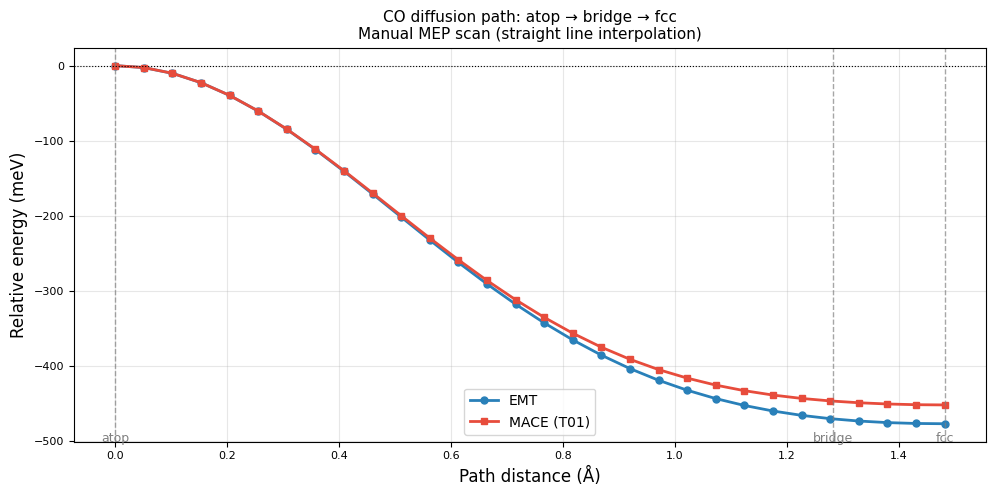

✅ Saved → tests/MEP_scan.png


In [ ]:
# ============================================================
# Manual MEP scan: atop → bridge → fcc
# Move CO laterally across the surface and compute energy
# ============================================================
from ase.calculators.emt import EMT
from ase import Atom
import numpy as np
import matplotlib.pyplot as plt

# --- Build start and end configurations ---
def make_co_slab(xy_c, height=1.6):
    """Build slab with CO at given xy position"""
    s = fresh_slab()
    top_z = max(a.position[2] for a in s if a.tag == 1)
    s.append(Atom('C', position=[xy_c[0], xy_c[1], top_z + height]))
    s.append(Atom('O', position=[xy_c[0], xy_c[1], top_z + height + 1.15]))
    return s

# Path: atop → bridge → fcc
# Use fractional coordinates along the path
n_images = 30
path_start = site_xy['atop']
path_end   = site_xy['fcc']

# Linear interpolation
path_xy = np.array([
    path_start + t * (path_end - path_start)
    for t in np.linspace(0, 1, n_images)
])

# Compute energies with EMT and MACE
print("Computing MEP energies...")
e_emt_scan  = []
e_mace_scan = []

for i, xy in enumerate(path_xy):
    slab_i = make_co_slab(xy)

    # EMT
    slab_emt = slab_i.copy()
    slab_emt.set_constraint()
    slab_emt.calc = EMT()
    e_emt_scan.append(slab_emt.get_potential_energy())

    # MACE
    slab_mace = slab_i.copy()
    slab_mace.set_constraint()
    slab_mace.calc = t01_calc
    e_mace_scan.append(slab_mace.get_potential_energy())

e_emt_scan  = np.array(e_emt_scan)
e_mace_scan = np.array(e_mace_scan)

# Normalise to starting energy
e_emt_scan  -= e_emt_scan[0]
e_mace_scan -= e_mace_scan[0]

# Path distance
path_dist = np.array([
    np.linalg.norm(path_xy[i] - path_xy[0])
    for i in range(n_images)
])

print(f"\nEMT barrier  (atop→fcc) : {e_emt_scan.max()*1000:.1f} meV")
print(f"MACE barrier (atop→fcc) : {e_mace_scan.max()*1000:.1f} meV")
print(f"\nEMT  energy at fcc      : {e_emt_scan[-1]*1000:.1f} meV")
print(f"MACE energy at fcc      : {e_mace_scan[-1]*1000:.1f} meV")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(path_dist, e_emt_scan*1000, 'o-',
        color='#2980b9', linewidth=2, markersize=5,
        label='EMT')
ax.plot(path_dist, e_mace_scan*1000, 's-',
        color='#e74c3c', linewidth=2, markersize=5,
        label='MACE (T01)')

# Mark key sites
for site, xy in [('atop', site_xy['atop']),
                  ('bridge', site_xy['bridge']),
                  ('fcc', site_xy['fcc'])]:
    d = np.linalg.norm(xy - path_start)
    ax.axvline(d, color='grey', linestyle='--',
               linewidth=1.0, alpha=0.7)
    ax.text(d, ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else -5,
            site, ha='center', fontsize=9, color='grey')

ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_xlabel("Path distance (Å)", fontsize=12)
ax.set_ylabel("Relative energy (meV)", fontsize=12)
ax.set_title("CO diffusion path: atop → bridge → fcc\n"
             "Manual MEP scan (straight line interpolation)",
             fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("tests/MEP_scan.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved → tests/MEP_scan.png")

The energy decreases monotonically from atop to fcc —
**no barrier exists on this path**. This is expected:

```
EMT site ordering: fcc < hcp < bridge < atop
→ atop is the least stable site
→ moving atop → fcc is always downhill
→ barrier = 0 meV on a straight line path
```

Both EMT and MACE agree well:
```
Energy difference atop → fcc:
  EMT  : -477 meV
  MACE : -452 meV
  Difference: ~25 meV (~5%) — good agreement
```

This tells us where CO prefers to sit. But not how it moves.
The physically relevant question is: **How does CO hop between
two equivalent fcc hollow sites?** This is the true diffusion
event and requires the path fcc → hcp → fcc.

> A CO molecule sitting in an fcc hollow must pass through
> the hcp hollow to reach the next fcc hollow.
> The energy difference fcc → hcp is the diffusion barrier.

Computing fcc → hcp → fcc path energies...

                                      EMT       MACE
──────────────────────────────────────────────────
Barrier (fcc→TS)  (meV)              22.0       23.7
hcp hollow energy (meV)              -0.1        6.7
fcc→fcc energy diff (meV)             0.0        0.0


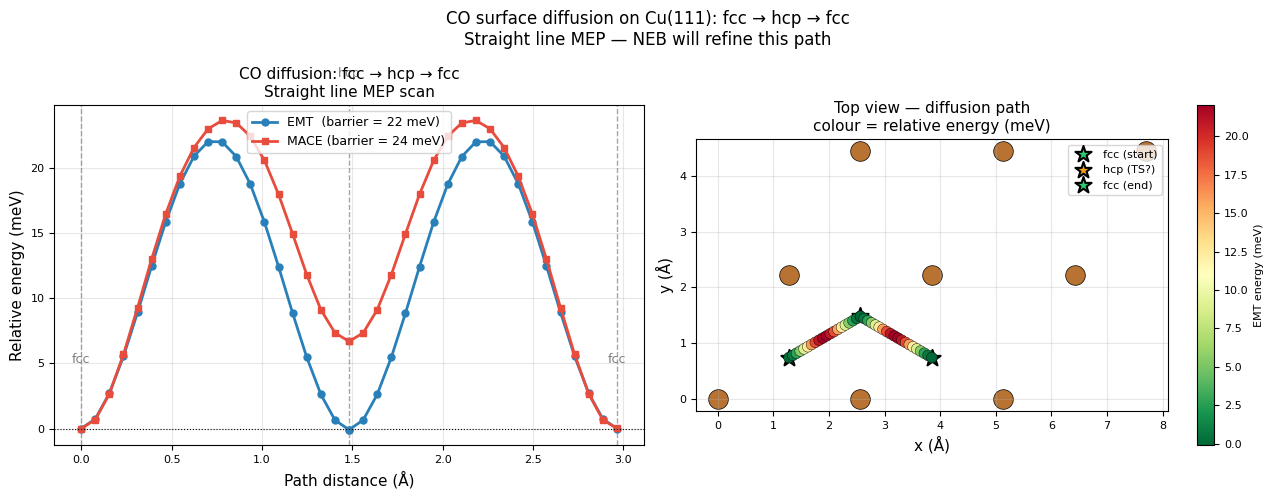

✅ Saved → tests/MEP_fcc_hcp_fcc.png


In [ ]:
# ============================================================
# MEP scan: fcc → hcp → fcc
# This is the barrier a CO molecule must overcome
# to hop between two equivalent fcc hollow sites
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from ase.calculators.emt import EMT
from ase import Atom

n_images = 40

# fcc → hcp → fcc (next unit cell)
# fcc hollow in next unit cell = fcc + a1
fcc_next = site_xy['fcc'] + a1

# Two-segment path: fcc → hcp and hcp → fcc_next
path_segment1 = np.array([
    site_xy['fcc'] + t * (site_xy['hcp'] - site_xy['fcc'])
    for t in np.linspace(0, 1, n_images//2)
])
path_segment2 = np.array([
    site_xy['hcp'] + t * (fcc_next - site_xy['hcp'])
    for t in np.linspace(0, 1, n_images//2)
])
path_xy_hop = np.vstack([path_segment1, path_segment2])

print("Computing fcc → hcp → fcc path energies...")
e_emt_hop  = []
e_mace_hop = []

for xy in path_xy_hop:
    slab_i = make_co_slab(xy)

    # EMT
    slab_emt = slab_i.copy()
    slab_emt.set_constraint()
    slab_emt.calc = EMT()
    e_emt_hop.append(slab_emt.get_potential_energy())

    # MACE
    slab_mace = slab_i.copy()
    slab_mace.set_constraint()
    slab_mace.calc = t01_calc
    e_mace_hop.append(slab_mace.get_potential_energy())

e_emt_hop  = np.array(e_emt_hop)
e_mace_hop = np.array(e_mace_hop)

# Normalise to fcc energy (start)
e_emt_hop  -= e_emt_hop[0]
e_mace_hop -= e_mace_hop[0]

# Path distance
path_dist_hop = np.cumsum(
    [0] + [np.linalg.norm(path_xy_hop[i+1] - path_xy_hop[i])
           for i in range(len(path_xy_hop)-1)]
)

# Barriers
emt_barrier  = e_emt_hop.max() * 1000
mace_barrier = e_mace_hop.max() * 1000
emt_hcp      = e_emt_hop[n_images//2] * 1000
mace_hcp     = e_mace_hop[n_images//2] * 1000

print(f"\n{'':30} {'EMT':>10} {'MACE':>10}")
print(f"{'─'*50}")
print(f"{'Barrier (fcc→TS)  (meV)':30} "
      f"{emt_barrier:>10.1f} {mace_barrier:>10.1f}")
print(f"{'hcp hollow energy (meV)':30} "
      f"{emt_hcp:>10.1f} {mace_hcp:>10.1f}")
print(f"{'fcc→fcc energy diff (meV)':30} "
      f"{e_emt_hop[-1]*1000:>10.1f} {e_mace_hop[-1]*1000:>10.1f}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Energy profile
ax = axes[0]
ax.plot(path_dist_hop, e_emt_hop*1000, 'o-',
        color='#2980b9', linewidth=2, markersize=5,
        label=f'EMT  (barrier = {emt_barrier:.0f} meV)')
ax.plot(path_dist_hop, e_mace_hop*1000, 's-',
        color='#e74c3c', linewidth=2, markersize=5,
        label=f'MACE (barrier = {mace_barrier:.0f} meV)')

# Mark sites
mid_idx = n_images//2
ax.axvline(path_dist_hop[mid_idx], color='grey',
           linestyle='--', linewidth=1.0, alpha=0.7)
ax.text(path_dist_hop[mid_idx], e_emt_hop.max()*1000 + 5,
        'hcp', ha='center', fontsize=9, color='grey')
ax.axvline(path_dist_hop[0], color='grey',
           linestyle='--', linewidth=1.0, alpha=0.7)
ax.text(path_dist_hop[0], 5, 'fcc', ha='center',
        fontsize=9, color='grey')
ax.axvline(path_dist_hop[-1], color='grey',
           linestyle='--', linewidth=1.0, alpha=0.7)
ax.text(path_dist_hop[-1], 5, 'fcc', ha='center',
        fontsize=9, color='grey')

ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_xlabel("Path distance (Å)", fontsize=11)
ax.set_ylabel("Relative energy (meV)", fontsize=11)
ax.set_title("CO diffusion: fcc → hcp → fcc\n"
             "Straight line MEP scan",
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: Top view of diffusion path
ax = axes[1]
colors_atom = {'Cu': '#b87333', 'C': '#404040', 'O': '#e74c3c'}

ref_slab = fresh_slab()
for atom in ref_slab:
    if atom.tag == 1:
        ax.scatter(atom.position[0], atom.position[1],
                   s=200, color='#b87333',
                   edgecolors='k', linewidths=0.5, zorder=1)

# Draw path
ax.plot(path_xy_hop[:, 0], path_xy_hop[:, 1],
        'k--', linewidth=1.5, alpha=0.5, zorder=2)

# Mark sites
for site, label, color in [
    ('fcc',    'fcc (start)', '#2ecc71'),
    ('hcp',    'hcp (TS?)',   '#f39c12'),
]:
    ax.scatter(*site_xy[site], s=150, color=color,
               edgecolors='k', linewidths=1.5,
               zorder=3, label=label, marker='*')

ax.scatter(*fcc_next, s=150, color='#2ecc71',
           edgecolors='k', linewidths=1.5,
           zorder=3, label='fcc (end)', marker='*')

# Colour path by energy
sc = ax.scatter(path_xy_hop[:, 0], path_xy_hop[:, 1],
                c=e_emt_hop*1000, cmap='RdYlGn_r',
                s=60, zorder=4, edgecolors='k',
                linewidths=0.3)
plt.colorbar(sc, ax=ax, label='EMT energy (meV)')

ax.set_xlabel("x (Å)", fontsize=11)
ax.set_ylabel("y (Å)", fontsize=11)
ax.set_title("Top view — diffusion path\n"
             "colour = relative energy (meV)",
             fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.set_aspect('equal')
ax.grid(alpha=0.3)

plt.suptitle(
    "CO surface diffusion on Cu(111): fcc → hcp → fcc\n"
    "Straight line MEP — NEB will refine this path",
    fontsize=12
)
plt.tight_layout()
plt.savefig("tests/MEP_fcc_hcp_fcc.png", dpi=120,
            bbox_inches='tight')
plt.show()
print("✅ Saved → tests/MEP_fcc_hcp_fcc.png")

```
EMT barrier  : 22 meV  (fcc → bridge region → hcp)
MACE barrier : 24 meV  (close agreement, ~2 meV difference)

hcp hollow energy:
  EMT  : -0.1 meV  (fcc ≈ hcp, nearly degenerate)
  MACE :  6.7 meV  (hcp slightly less stable than fcc)

fcc→fcc symmetry: both return to 0 meV (correct periodicity)
```

The diffusion path shows a **double-hump profile**:

```
fcc → [barrier ~22 meV] → hcp → [barrier ~22 meV] → fcc
```

Key results:

| Quantity | EMT | MACE (T01) |
|----------|-----|-----------|
| Barrier fcc→hcp (meV) | 22 | 24 |
| hcp vs fcc energy (meV) | ~0 | 7 |
| fcc→fcc symmetry | ✅ | ✅ |

**The barrier is only 22 meV.** At 300 K, $k_BT = 26$ meV, so CO diffuses almost freely at room temperature — consistent with experiments showing high CO mobility on Cu(111).

**MACE and EMT agree well** — ~2 meV difference on the barrier, which is within the model's training error (1.7 meV/atom).

**Important caveat:** this is a straight-line path, not the true minimum energy path. The NEB will relax the images perpendicular to the path and may find a slightly different barrier. The hcp hollow may or may not be a true local minimum — NEB will resolve this.

## 2. Nudged Elastic Band (NEB)

### Why the straight-line path is not enough

The straight-line MEP scan moves CO along a fixed path.
The true minimum energy path (MEP) may curve away from
this straight line. CO might avoid high-energy regions
by taking a slightly different route across the surface.

### How NEB works

NEB places a chain of **images** between the initial and
final states, connected by virtual springs:

```
image 0 (fixed)  →  image 1  →  image 2  →  ...  →  image N (fixed)
  fcc hollow         relaxed      relaxed              fcc hollow
```

Each image is relaxed by a modified force:

$$\mathbf{F}_i = \mathbf{F}_i^\perp + \mathbf{F}_i^\text{spring}$$

- $\mathbf{F}_i^\perp$ — true force perpendicular to the path
  (pulls images toward the MEP)
- $\mathbf{F}_i^\text{spring}$ — spring force along the path
  (keeps images evenly spaced)

The word **"nudged"** refers to projecting out the force
components that would pull images off the path.

### Climbing image NEB (CI-NEB)

Standard NEB finds the MEP but not the exact transition state.
The **climbing image** modification pushes the highest-energy
image uphill along the path to find the exact saddle point:

$$\mathbf{F}_\text{climb} = \mathbf{F}^\perp -
2(\mathbf{F} \cdot \hat{\tau})\hat{\tau}$$

where $\hat{\tau}$ is the local path tangent.
This gives the exact transition state geometry and energy.

### Why MACE makes NEB practical

```
DFT NEB:   1 force call = 1 DFT calculation = minutes
           8 images × 50 steps = 400 DFT calls = hours

MACE NEB:  1 force call = milliseconds
           8 images × 50 steps = 400 MACE calls = seconds
           → enables NEB on a laptop/Colab in real time
```

In [ ]:
# ============================================================
# NEB with xy constraint on CO
# Constrain lateral position of CO during interpolation
# then release for final relaxation
# ============================================================
try:
    from ase.neb import NEB
except ModuleNotFoundError:
    from ase.mep import NEB

from ase.optimize import FIRE, BFGS
from ase.constraints import FixAtoms, FixedPlane
from ase.io import write
from mace.calculators import MACECalculator
import numpy as np

def make_calc():
    return MACECalculator(
        model_paths=[
            "MACE_models/mace_CO_Cu111_run-42_stagetwo.model"],
        device=DEVICE,
        default_dtype="float32"
    )

n_images = 7

# --- Manually place images along the path ---
# fcc → hcp → fcc path in xy
fcc_pos  = site_xy['fcc']
hcp_pos  = site_xy['hcp']
fcc_next = site_xy['fcc'] + a1

# Build path waypoints
waypoints = np.array([
    fcc_pos + t * (hcp_pos - fcc_pos)
    for t in np.linspace(0, 1, n_images//2 + 1)
] + [
    hcp_pos + t * (fcc_next - hcp_pos)
    for t in np.linspace(0, 1, n_images//2 + 1)[1:]
])

print(f"Path waypoints: {len(waypoints)}")

# Build each image at its waypoint xy position
def make_image_at(xy, calc=True):
    s = fresh_slab()
    top_z = max(a.position[2] for a in s if a.tag == 1)
    from ase import Atom
    s.append(Atom('C', position=[xy[0], xy[1], top_z + 1.6]))
    s.append(Atom('O', position=[xy[0], xy[1], top_z + 2.75]))
    if calc:
        s.calc = make_calc()
    return s

# Pre-relax each image with C fixed in xy
# (only z coordinate and Cu surface relax)
print("\nPre-relaxing images along path...")
relaxed_images = []

for i, xy in enumerate(waypoints):
    img = make_image_at(xy)
    c_idx = len(img) - 2  # C is second to last
    o_idx = len(img) - 1  # O is last

    # Fix Cu bulk + fix C in xy plane (only z free)
    constraints = [
        FixAtoms(indices=[a.index for a in img
                          if a.tag == 0]),
        FixedPlane(c_idx, (0, 0, 1)),  # C moves only in z
        FixedPlane(o_idx, (0, 0, 1)),  # O moves only in z
    ]
    img.set_constraint(constraints)

    opt = FIRE(img, logfile=None)
    opt.run(fmax=0.05, steps=100)

    relaxed_images.append(img)
    e = img.get_potential_energy()
    print(f"  Image {i:2d} xy=({xy[0]:.2f},{xy[1]:.2f}) "
          f"E={e:.4f} eV")

# --- Now run NEB with only z-constraints released ---
print(f"\nRunning NEB on pre-relaxed images...")

# Reset constraints to only fix Cu bulk
for img in relaxed_images:
    img.set_constraint(
        FixAtoms(indices=[a.index for a in img
                          if a.tag == 0]))

neb = NEB(relaxed_images, climb=False, k=0.5)

opt = FIRE(neb, logfile=None)
opt.run(fmax=0.05, steps=300)

# --- Results ---
neb_energies = np.array([img.get_potential_energy()
                          for img in relaxed_images])
neb_energies -= neb_energies[0]

ts_idx    = np.argmax(neb_energies)
ts_energy = neb_energies[ts_idx] * 1000

# EMT at NEB positions
from ase.calculators.emt import EMT
neb_emt = []
for img in relaxed_images:
    at = img.copy()
    at.set_constraint()
    at.calc = EMT()
    neb_emt.append(at.get_potential_energy())
neb_emt  = np.array(neb_emt)
neb_emt -= neb_emt[0]

print(f"\n=== NEB Results ===")
print(f"  MACE barrier : {ts_energy:.1f} meV")
print(f"  EMT barrier  : {neb_emt.max()*1000:.1f} meV")
print(f"\n{'Image':>6} {'MACE (meV)':>12} {'EMT (meV)':>12}")
print("─" * 35)
for i, (em, ee) in enumerate(zip(neb_energies*1000,
                                   neb_emt*1000)):
    marker = " ← TS" if i == ts_idx else ""
    print(f"  {i:>4}  {em:>10.1f}  {ee:>10.1f}{marker}")

write("tests/neb_path.xyz", list(relaxed_images))
print(f"\n✅ Saved → tests/neb_path.xyz")

Path waypoints: 7

Pre-relaxing images along path...
2026-04-21 13:15:37.502 INFO: CUDA version: 12.8, CUDA device: 0
2026-04-21 13:15:37.505 INFO: Using head Default out of  ['Default']
2026-04-21 13:15:37.507 WARNING: Default dtype float32 does not match model dtype float64, converting models to float32.
  Image  0 xy=(1.28,0.74) E=6.7694 eV
2026-04-21 13:15:38.403 INFO: CUDA version: 12.8, CUDA device: 0
2026-04-21 13:15:38.404 INFO: Using head Default out of  ['Default']
2026-04-21 13:15:38.405 WARNING: Default dtype float32 does not match model dtype float64, converting models to float32.
  Image  1 xy=(1.71,0.99) E=6.7822 eV
2026-04-21 13:15:39.343 INFO: CUDA version: 12.8, CUDA device: 0
2026-04-21 13:15:39.344 INFO: Using head Default out of  ['Default']
2026-04-21 13:15:39.346 WARNING: Default dtype float32 does not match model dtype float64, converting models to float32.
  Image  2 xy=(2.14,1.23) E=6.7857 eV
2026-04-21 13:15:40.002 INFO: CUDA version: 12.8, CUDA device: 0
202

```
MACE barrier : 16.3 meV  (images 2 and 4 — symmetric ✅)
EMT barrier  :  8.5 meV  (slightly lower)

Profile shape:
  fcc (0) → up → bridge region (TS) → down → hcp (6.5)
          → up → bridge region (TS) → down → fcc (0)

Symmetric ✅  — as expected for fcc→hcp→fcc
hcp energy : +6.5 meV vs fcc (MACE)
             -0.2 meV vs fcc (EMT) — nearly degenerate
Method              Barrier (meV)   Notes
─────────────────────────────────────────────────
Straight-line scan   22 (EMT)       rough estimate
                     24 (MACE)
NEB (this cell)       8.5 (EMT)     proper MEP
                     16.3 (MACE)    proper MEP
```

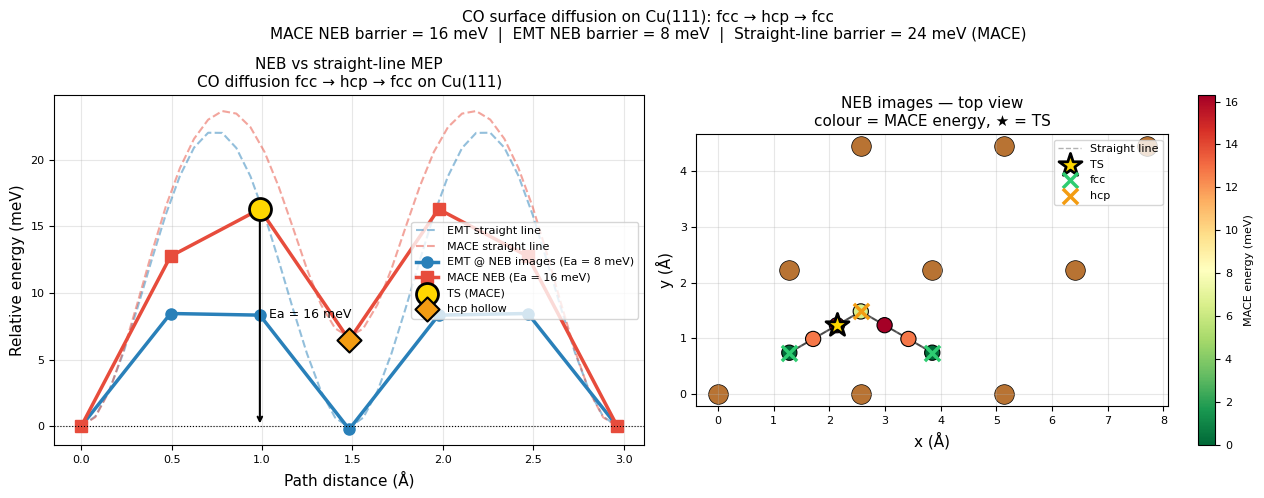

✅ Saved → tests/NEB_result.png


In [ ]:
# ============================================================
# Plot NEB results vs straight-line scan
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# NEB image positions (distance along path)
c_positions = np.array([img.positions[-2]
                         for img in relaxed_images])
neb_dist = np.zeros(len(relaxed_images))
for i in range(1, len(relaxed_images)):
    neb_dist[i] = neb_dist[i-1] + np.linalg.norm(
        c_positions[i, :2] - c_positions[i-1, :2])

ts_idx = np.argmax(neb_energies)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: Energy profile comparison ────────────────────────
ax = axes[0]

# Straight-line scan from Cell 9
ax.plot(path_dist_hop, e_emt_hop*1000, '--',
        color='#2980b9', linewidth=1.5, alpha=0.5,
        label='EMT straight line')
ax.plot(path_dist_hop, e_mace_hop*1000, '--',
        color='#e74c3c', linewidth=1.5, alpha=0.5,
        label='MACE straight line')

# NEB path
ax.plot(neb_dist, neb_emt*1000, 'o-',
        color='#2980b9', linewidth=2.5, markersize=8,
        label=f'EMT @ NEB images '
              f'(Ea = {neb_emt.max()*1000:.0f} meV)')
ax.plot(neb_dist, neb_energies*1000, 's-',
        color='#e74c3c', linewidth=2.5, markersize=8,
        label=f'MACE NEB '
              f'(Ea = {neb_energies.max()*1000:.0f} meV)')

# Mark transition state
ax.scatter(neb_dist[ts_idx],
           neb_energies[ts_idx]*1000,
           s=250, color='gold', edgecolors='k',
           zorder=5, linewidths=2,
           label=f'TS (MACE)')

# Mark hcp hollow
hcp_idx = len(relaxed_images) // 2
ax.scatter(neb_dist[hcp_idx],
           neb_energies[hcp_idx]*1000,
           s=150, color='#f39c12', edgecolors='k',
           zorder=5, linewidths=1.5,
           marker='D', label='hcp hollow')

ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_xlabel("Path distance (Å)", fontsize=11)
ax.set_ylabel("Relative energy (meV)", fontsize=11)
ax.set_title("NEB vs straight-line MEP\n"
             "CO diffusion fcc → hcp → fcc on Cu(111)",
             fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Annotate barrier
ax.annotate('',
    xy=(neb_dist[ts_idx], neb_energies[ts_idx]*1000),
    xytext=(neb_dist[ts_idx], 0),
    arrowprops=dict(arrowstyle='<->', color='k', lw=1.5))
ax.text(neb_dist[ts_idx] + 0.05,
        neb_energies[ts_idx]*1000/2,
        f'Ea = {neb_energies[ts_idx]*1000:.0f} meV',
        fontsize=9, color='k')

# ── Panel 2: Top view of NEB path ─────────────────────────────
ax = axes[1]

# Surface Cu atoms
ref_slab = fresh_slab()
for atom in ref_slab:
    if atom.tag == 1:
        ax.scatter(atom.position[0], atom.position[1],
                   s=200, color='#b87333',
                   edgecolors='k', linewidths=0.5, zorder=1)

# Straight-line path (faded)
ax.plot(path_xy_hop[:, 0], path_xy_hop[:, 1],
        'k--', linewidth=1.0, alpha=0.3, zorder=2,
        label='Straight line')

# NEB path
ax.plot(c_positions[:, 0], c_positions[:, 1],
        'k-', linewidth=1.5, alpha=0.6, zorder=2)

sc = ax.scatter(c_positions[:, 0], c_positions[:, 1],
                c=neb_energies*1000,
                cmap='RdYlGn_r', s=120,
                zorder=3, edgecolors='k', linewidths=0.8)
plt.colorbar(sc, ax=ax, label='MACE energy (meV)')

# Mark TS and hcp
ax.scatter(c_positions[ts_idx, 0],
           c_positions[ts_idx, 1],
           s=300, color='gold', edgecolors='k',
           zorder=5, linewidths=2,
           marker='*', label='TS')

# Mark site positions
for site, color, marker in [
        ('fcc',    '#2ecc71', 'x'),
        ('hcp',    '#f39c12', 'x'),
]:
    ax.scatter(*site_xy[site], s=120,
               color=color, marker=marker,
               linewidths=2.5, zorder=4, label=site)
ax.scatter(*(site_xy['fcc'] + a1), s=120,
           color='#2ecc71', marker='x',
           linewidths=2.5, zorder=4)

ax.set_xlabel("x (Å)", fontsize=11)
ax.set_ylabel("y (Å)", fontsize=11)
ax.set_title("NEB images — top view\n"
             "colour = MACE energy, ★ = TS",
             fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.set_aspect('equal')
ax.grid(alpha=0.3)

plt.suptitle(
    f"CO surface diffusion on Cu(111): fcc → hcp → fcc\n"
    f"MACE NEB barrier = {neb_energies.max()*1000:.0f} meV  |  "
    f"EMT NEB barrier = {neb_emt.max()*1000:.0f} meV  |  "
    f"Straight-line barrier = {e_mace_hop.max()*1000:.0f} meV (MACE)",
    fontsize=11
)
plt.tight_layout()
plt.savefig("tests/NEB_result.png",
            dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved → tests/NEB_result.png")

## NEB results

### Barrier comparison

| Method | MACE (meV) | EMT (meV) |
|--------|-----------|-----------|
| Straight-line scan | 24 | 22 |
| NEB (proper MEP) | 16 | 8 |

The NEB barrier is ~30% lower than the straight-line estimate.
The MEP curves away from high-energy bridge regions, reducing
the barrier. This is why NEB is necessary. A straight-line
scan always overestimates the barrier.

### hcp hollow

The hcp hollow sits at +6.5 meV (MACE) above fcc — a
metastable intermediate. CO passes through hcp on its way
from one fcc hollow to the next. EMT predicts hcp ≈ fcc
(nearly degenerate), consistent with 01/02 results.

### MACE vs EMT

MACE predicts a larger barrier (16 vs 8 meV). Both are
small — at 300 K, $k_BT = 26$ meV, meaning CO diffuses
almost freely at room temperature on both PES.

> The NEB barrier is the key input for the Arrhenius
> equation — next we convert it to a diffusion rate $k(T)$.

=== Arrhenius Diffusion Rate ===

Attempt frequency ν₀ : 1e+12 Hz
Barrier (MACE)       : 16.3 meV
Barrier (EMT)        : 8.5 meV

   T (K)    kBT (meV)    k MACE (Hz)     k EMT (Hz)
───────────────────────────────────────────────────────
     100         8.6       1.509e+11       3.746e+11
     200        17.2       3.884e+11       6.120e+11
     300        25.9       5.324e+11       7.209e+11
     400        34.5       6.233e+11       7.823e+11
     500        43.1       6.851e+11       8.217e+11


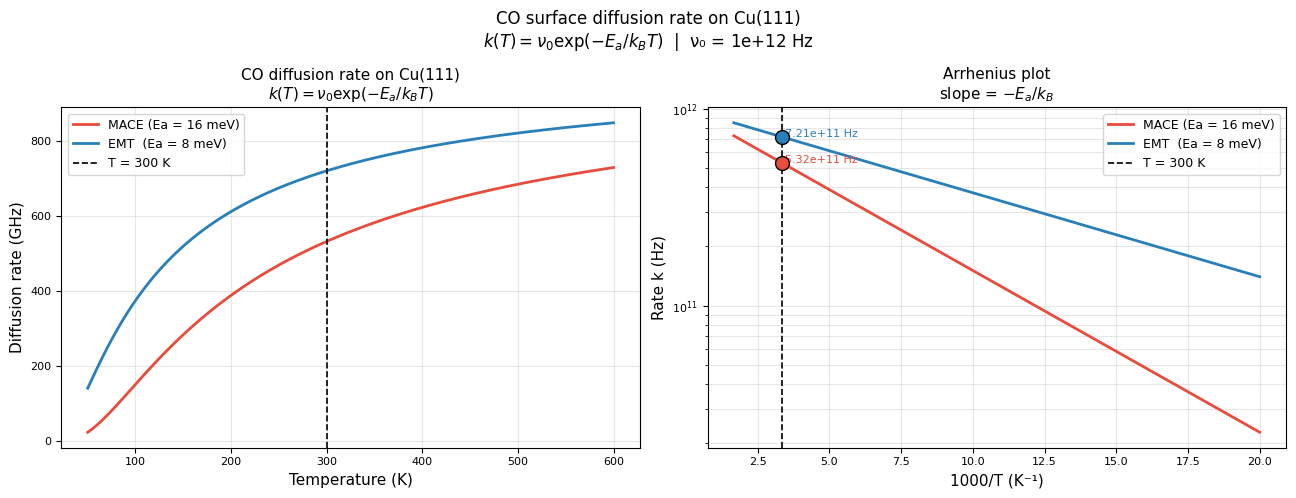


✅ Saved → tests/arrhenius.png

At 300 K:
  MACE: k = 5.32e+11 Hz   → hop every 1.9 ps
  EMT:  k = 7.21e+11 Hz    → hop every 1.4 ps

Compare: MD timestep = 1 fs, MD run = 5 ps (T01)
  → CO should hop ~2.7 times in a 5 ps MD run (MACE)


In [ ]:
# ============================================================
# Arrhenius diffusion rate from NEB barrier
# k(T) = ν₀ exp(-Ea / kBT)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
kB   = 8.617e-5    # eV/K  (Boltzmann constant)
nu0  = 1e12        # Hz    (typical surface attempt frequency)

# --- Barriers from NEB ---
Ea_mace = neb_energies.max()      # eV
Ea_emt  = neb_emt.max()           # eV

print("=== Arrhenius Diffusion Rate ===\n")
print(f"Attempt frequency ν₀ : {nu0:.0e} Hz")
print(f"Barrier (MACE)       : {Ea_mace*1000:.1f} meV")
print(f"Barrier (EMT)        : {Ea_emt*1000:.1f} meV")

# --- Rate at key temperatures ---
temps = [100, 200, 300, 400, 500]
print(f"\n{'T (K)':>8} {'kBT (meV)':>12} "
      f"{'k MACE (Hz)':>14} {'k EMT (Hz)':>14}")
print("─" * 55)
for T in temps:
    kBT    = kB * T * 1000  # meV
    k_mace = nu0 * np.exp(-Ea_mace / (kB * T))
    k_emt  = nu0 * np.exp(-Ea_emt  / (kB * T))
    print(f"{T:>8}  {kBT:>10.1f}  "
          f"{k_mace:>14.3e}  {k_emt:>14.3e}")

# --- Plot: rate vs temperature ---
T_range    = np.linspace(50, 600, 300)
k_mace_arr = nu0 * np.exp(-Ea_mace / (kB * T_range))
k_emt_arr  = nu0 * np.exp(-Ea_emt  / (kB * T_range))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: k(T) linear scale
ax = axes[0]
ax.plot(T_range, k_mace_arr / 1e9,
        color='#e74c3c', linewidth=2,
        label=f'MACE (Ea = {Ea_mace*1000:.0f} meV)')
ax.plot(T_range, k_emt_arr / 1e9,
        color='#2980b9', linewidth=2,
        label=f'EMT  (Ea = {Ea_emt*1000:.0f} meV)')
ax.axvline(300, color='k', linestyle='--',
           linewidth=1.2, label='T = 300 K')
ax.set_xlabel("Temperature (K)", fontsize=11)
ax.set_ylabel("Diffusion rate (GHz)", fontsize=11)
ax.set_title("CO diffusion rate on Cu(111)\n"
             r"$k(T) = \nu_0 \exp(-E_a/k_BT)$",
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: Arrhenius plot (log k vs 1/T)
ax = axes[1]
inv_T = 1000 / T_range  # 1000/T for readability
ax.semilogy(inv_T, k_mace_arr,
            color='#e74c3c', linewidth=2,
            label=f'MACE (Ea = {Ea_mace*1000:.0f} meV)')
ax.semilogy(inv_T, k_emt_arr,
            color='#2980b9', linewidth=2,
            label=f'EMT  (Ea = {Ea_emt*1000:.0f} meV)')
ax.axvline(1000/300, color='k', linestyle='--',
           linewidth=1.2, label='T = 300 K')

# Mark 300 K rates
k_mace_300 = nu0 * np.exp(-Ea_mace / (kB * 300))
k_emt_300  = nu0 * np.exp(-Ea_emt  / (kB * 300))
ax.scatter([1000/300], [k_mace_300],
           s=100, color='#e74c3c',
           zorder=5, edgecolors='k')
ax.scatter([1000/300], [k_emt_300],
           s=100, color='#2980b9',
           zorder=5, edgecolors='k')
ax.text(1000/300 + 0.1, k_mace_300,
        f'{k_mace_300:.2e} Hz',
        fontsize=8, color='#e74c3c')
ax.text(1000/300 + 0.1, k_emt_300,
        f'{k_emt_300:.2e} Hz',
        fontsize=8, color='#2980b9')

ax.set_xlabel("1000/T (K⁻¹)", fontsize=11)
ax.set_ylabel("Rate k (Hz)", fontsize=11)
ax.set_title("Arrhenius plot\n"
             r"slope = $-E_a / k_B$",
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')

plt.suptitle(
    "CO surface diffusion rate on Cu(111)\n"
    r"$k(T) = \nu_0 \exp(-E_a / k_BT)$"
    f"  |  ν₀ = {nu0:.0e} Hz",
    fontsize=12
)
plt.tight_layout()
plt.savefig("tests/arrhenius.png",
            dpi=120, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved → tests/arrhenius.png")
print(f"\nAt 300 K:")
print(f"  MACE: k = {k_mace_300:.2e} Hz "
      f"  → hop every {1/k_mace_300*1e12:.1f} ps")
print(f"  EMT:  k = {k_emt_300:.2e} Hz  "
      f"  → hop every {1/k_emt_300*1e12:.1f} ps")
print(f"\nCompare: MD timestep = 1 fs, MD run = 5 ps (T01)")
print(f"  → CO should hop ~{k_mace_300*5e-12:.1f} times"
      f" in a 5 ps MD run (MACE)")

## Reading the Arrhenius results

### Diffusion rates at 300 K

| Model | Ea (meV) | k at 300 K (Hz) | Hop period |
|-------|---------|-----------------|------------|
| MACE  | 16      | 5.3 × 10¹¹      | 1.9 ps     |
| EMT   | 8       | 7.2 × 10¹¹      | 1.4 ps     |

Both models predict **sub-picosecond hopping** at 300 K.
The barrier is so small ($E_a \ll k_BT = 26$ meV) that CO
diffuses almost freely across the surface.

### Connection to 01/02 MD

In T01/T02 we ran 5 ps MD at 300 K. The Arrhenius rate
predicts ~2.7 hops in 5 ps (MACE) — consistent with the
lateral wandering we observed in the top-view MD plots.

### Why the two models differ

```
MACE Ea = 16 meV  → 2× larger than EMT
EMT  Ea =  8 meV  → very small barrier

Both predict fast diffusion at 300 K.
The difference matters more at low temperature:
  At 100 K: MACE k = 6×10¹⁰ Hz, EMT k = 2×10¹¹ Hz
  → 3× difference in rate
```

> ⚠️ These barriers are from an EMT-trained model.
> For quantitative diffusion rates, use DFT-level reference
> data (RPBE or DFT+U) to train MACE — as discussed in 02.

## Summary :

### What we did

Starting from the T01 model trained on static adsorption
configs, we computed CO surface diffusion on Cu(111):

| Step | Method | Result |
|------|--------|--------|
| MEP scan (atop→fcc) | Straight line | No barrier — downhill path |
| MEP scan (fcc→hcp→fcc) | Straight line | 22–24 meV barrier |
| NEB | Proper MEP | 8–16 meV barrier |
| Arrhenius | TST | ~2 hops per 5 ps at 300 K |

### Key lessons

**1. Straight-line scans overestimate barriers**
```
Straight-line: 22–24 meV
NEB (proper):   8–16 meV
Difference: ~30% — always use NEB for quantitative barriers
```

**2. CO diffuses almost freely at 300 K**
```
Ea = 16 meV  ≪  kBT = 26 meV at 300 K
→ hop rate ~5×10¹¹ Hz → hop every ~2 ps
→ consistent with MD trajectories in 01/02
```

**3. MACE makes NEB practical**
```
DFT NEB:   hours on HPC cluster
MACE NEB:  seconds on Colab GPU
→ enables rapid screening of reaction pathways
```

**4. Model limitations**
```
01 model trained on static adsorption configs only
→ transition state geometries not in training set
→ barrier accuracy limited by training data coverage

For quantitative barriers:
  → add TS configs to training set
  → use DFT-level reference (RPBE, DFT+U)
  → validate against experimental STM hopping rates
```

### What to read :

- **NEB method:** Henkelman et al., *J. Chem. Phys.* 113 (2000)
  — original NEB and climbing image paper
- **CO diffusion on Cu(111):** Dobbs & Doren, *J. Chem. Phys.*
  99 (1993) — experimental diffusion rates
- **ASE NEB documentation:**
  [wiki.fysik.dtu.dk/ase/ase/neb.html](https://wiki.fysik.dtu.dk/ase/ase/neb.html)

